In [ ]:
import os
import sys

# Controlla se il notebook sta girando su Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    # Monta il drive
    drive.mount('/content/drive')
    
    # IMPORTANTE: Inserisci qui il percorso esatto della cartella su Drive.
    # Se è una cartella condivisa standard di cui avete creato una scorciatoia 
    # nel vostro Drive personale, il percorso sarà simile a questo:
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
    
    # Se invece è un "Drive Condiviso" aziendale/universitario:
    # BASE_PATH = '/content/drive/Shareddrives/Nome_Drive/Nome_Progetto/'

else:
    print("Ambiente locale rilevato.")
    # Imposta la directory base in locale. 
    # './' significa la cartella in cui si trova attualmente il notebook.
    # Oppure usa '../' se i notebook sono in una sottocartella e i dati fuori.
    BASE_PATH = '../'

print(f"Percorso base: ", BASE_PATH)

Ambiente locale rilevato.
Percorso base:  ../


#### Import

In [2]:
import zipfile
import gdown
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight
from datetime import date

I0000 00:00:1781643754.496824    1538 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781643755.411394    1538 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781643758.614079    1538 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


#### Configurazione

In [3]:
# Cartella esperimento
OUTPUT_DIR = os.path.join(BASE_PATH, 'experiments', 'exp20260616_baseline_efficientnetb3_fine_tuned_batch_size_16')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(OUTPUT_DIR)

../experiments/exp20260616_baseline_efficientnetb3_fine_tuned_batch_size_16


In [4]:
# Ora costruisci i percorsi dei file unendo il BASE_PATH al resto
TRAIN_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "train.csv")
VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "val.csv")

IMG_SIZE = (300, 300)
BATCH_SIZE = 16 # era 8
SEED = 42

# Medie e std di ImageNet
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225])

# Imposta il seed per la riproducibilità
keras.utils.set_random_seed(SEED)
print(TRAIN_CSV_PATH)
print(VAL_CSV_PATH)

../data/processed/metadata/train.csv
../data/processed/metadata/val.csv


I0000 00:00:1781643782.785199    1538 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


#### Verifica presenza file dataset preprocessato

In [ ]:
# ID del file su Google Drive
PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')

def processed_data_ready():
    if not os.path.isfile(TRAIN_CSV_PATH) or not os.path.isfile(VAL_CSV_PATH):
        return False
    try:
        first_path = pd.read_csv(TRAIN_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(os.path.join(BASE_PATH, first_path))
    except Exception:
        return False

if not processed_data_ready():
    print("Dataset non trovato, scarico da Google Drive...")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)
    print(f"Dataset estratto in: {os.path.join(BASE_PATH, 'data')}")
else:
    print("Dataset già presente, salto il download.")


#### Preparazione Dati e Pipeline

Filtriamo il dataset per usare solo i dati reali di train e validation. Includiamo la funzione aggiornata con l'aggiunta del rumore gaussiano per la data augmentation.

In [6]:
# 1. Carica e filtra il CSV
df_train = pd.read_csv(TRAIN_CSV_PATH).reset_index(drop=True)
df_val = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)

# 2. Calcola i pesi delle classi per il training
labels_train = df_train['cancer'].values
classes = np.unique(labels_train)
weights = compute_class_weight('balanced', classes=classes, y=labels_train)
class_weight_dict = dict(zip(classes.astype(int), weights))
print(f"Class Weights: {class_weight_dict}")

# 3. Funzioni tf.data (con rumore gaussiano per augmentation)
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
        
    return img, tf.cast(label, tf.float32)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    #img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, -3.0, 3.0)
    return img, label
# Niente rotazioni forti, nemmeno zoom

def make_dataset(df, shuffle=False, augment_data=False):
    paths = df['processed_path'].values
    labels = df['cancer'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l), num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Costruisci i dataset
train_ds = make_dataset(df_train, shuffle=True, augment_data=False) # Da mettere a True se vuoi data augmentation
val_ds = make_dataset(df_val, shuffle=False, augment_data=False) 

Class Weights: {0: 0.5999412110523221, 1: 3.001470588235294}


#### Salvataggio configurazione utilizzata per esperimento corrente

In [7]:
experiment_config = {
    "experiment_name": os.path.basename(OUTPUT_DIR),
    "date": date.today().isoformat(),
    "backbone": {
        "name": "EfficientNetB3",
        "weights": "imagenet",
        "input_shape": list(IMG_SIZE) + [3],
        "include_top": False,
    },
    "head": {
        "pooling": "GlobalAveragePooling2D",
        "dense_units": 256,
        "l2_regularization": 1e-4,
        "activation": "LeakyReLU(negative_slope=0.1)",
        "dropout": 0.5,
        "output": "Dense(1, sigmoid)",
    },
    "preprocessing": {
        "img_size": list(IMG_SIZE),
        "normalization": "ImageNet mean/std",
        "imagenet_mean": [0.485, 0.456, 0.406],
        "imagenet_std": [0.229, 0.224, 0.225],
    },
    "data": {
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "augmentation": False,
        "train_csv": TRAIN_CSV_PATH,
        "val_csv": VAL_CSV_PATH,
    },
    "phase1_head_training": {
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy",
        "max_epochs": 25,
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 7,
        "class_weight": "balanced",
        "backbone_trainable": False,
    },
    "phase2_fine_tuning": {
        "optimizer": "Adam",
        "learning_rate": 1e-5,
        "loss": "BinaryFocalCrossentropy",
        "BinaryFocalCrossentropy_gamma": 2.0,
        "BinaryFocalCrossentropy_alpha": 0.75,
        "max_epochs": 30,
        "fine_tune_from_layer": "block6a_expand_conv",
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 5,
        "early_stopping_min_delta": 1e-3,
        "reduce_lr_factor": 0.5,
        "reduce_lr_patience": 3,
        "min_lr": 1e-7,
        "class_weight": "none",
    },
}

config_path = os.path.join(OUTPUT_DIR, 'experiment_config.json')
with open(config_path, 'w') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)
print(f"Configurazione esperimento salvata in: {config_path}")


Configurazione esperimento salvata in: ../experiments/exp20260616_baseline_efficientnetb3_fine_tuned_batch_size_16/experiment_config.json


#### Costruzione dell'Architettura EfficientNetB3

Creiamo la funzione che istanzia il modello. Inizialmente, congeliamo tutto il backbone (EfficientNetB3) per addestrare solo la nostra testina di classificazione (custom head).

In [8]:
def build_base_model():
    # Carica il backbone EfficientNetB3 pre-addestrato
    base_model = keras.applications.EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_shape=IMG_SIZE + (3,)
    )
    
    # Congela il backbone per la Fase 1
    base_model.trainable = False
    
    # Costruisci l'architettura completa
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    
    x = base_model(inputs, training=False) 
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.5)(x)
    
    # Output binario (1 neurone con sigmoid)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs, name="baseline_efficientnetb3")
    return model, base_model

model, base_model = build_base_model()
model.summary()


Model: "baseline_efficientnetb3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,288 (42.64 MB)

 Trainable params: 394,241 (1.50 MB)

 Non-trainable params: 10,784,047 (41.14 MB)

#### Fase 1: Addestramento Custom Head

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=7,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'baseline_efficientnetb3_fase1_best.keras'),
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    ),
    keras.callbacks.CSVLogger(
        os.path.join(OUTPUT_DIR, 'training_log_fase1.csv'),
        separator=',',
        append=False
    )
]

history_phase1 = model.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_fase1
)

Epoch 1/25


I0000 00:00:1781643823.042585    1778 service.cc:153] XLA service 0x7f6ae008e020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781643823.042630    1778 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781643824.665511    1778 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781643829.447610    1778 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781643830.797669    1778 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26605__.413
E0000 00:00:1781643834.995027    1778 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781643835.698112    1778 cuda_timer.cc:87] Delay kernel time

127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5064 - auc: 0.4988 - loss: 0.9531 - precision: 0.1559 - recall: 0.4699

I0000 00:00:1781643887.007486    1776 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26605__.413
E0000 00:00:1781643892.050326    1776 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781643895.148656    1776 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781643899.705315    1776 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781643899.944902    1776 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781643901.067798    1776 cuda_timer.cc:87] Delay kernel timed ou

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.5066 - auc: 0.4990 - loss: 0.9529 - precision: 0.1561 - recall: 0.4702

E0000 00:00:1781643940.821487    1780 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781643941.798211    1780 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781643944.754264    1780 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781643946.072518    1780 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781643946.968994    1780 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


128/128 ━━━━━━━━━━━━━━━━━━━━ 157s 694ms/step - accuracy: 0.5301 - auc: 0.5334 - loss: 0.9211 - precision: 0.1799 - recall: 0.5118 - val_accuracy: 0.2609 - val_auc: 0.5591 - val_loss: 0.9226 - val_precision: 0.1711 - val_recall: 0.8904
Epoch 2/25
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.5448 - auc: 0.5647 - loss: 0.8318 - precision: 0.1923 - recall: 0.5412 - val_accuracy: 0.2792 - val_auc: 0.6001 - val_loss: 1.0926 - val_precision: 0.1832 - val_recall: 0.9589
Epoch 3/25
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.5556 - auc: 0.5814 - loss: 0.7917 - precision: 0.2006 - recall: 0.5588 - val_accuracy: 0.5698 - val_auc: 0.6534 - val_loss: 0.7550 - val_precision: 0.2300 - val_recall: 0.6712
Epoch 4/25
128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.5737 - auc: 0.6200 - loss: 0.7400 - precision: 0.2151 - recall: 0.5882 - val_accuracy: 0.6087 - val_auc: 0.6137 - val_loss: 0.7236 - val_precision: 0.2247 - val_recall: 0.5479
Epoch 5/25
128/128 ━━━━━━━━━━━━━━

#### Fase 2: Fine Tuning

In [10]:
base_model.trainable = True
set_trainable = False

for layer in base_model.layers:
    if layer.name == 'block6a_expand_conv':
        set_trainable = True
    layer.trainable = set_trainable

# Freeze dei BatchNorm: anche nei layer sbloccati sopra,
# le statistiche BN restano quelle di ImageNet (più stabili con batch size piccolo)
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(f"Totale layer nel base_model: {len(base_model.layers)}")
n_trainable_layers = sum(1 for l in base_model.layers if l.trainable)
print(f"Layer trainable nel base_model: {n_trainable_layers}/{len(base_model.layers)}")

'''
def focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        # alpha_t: alpha per positivi, (1-alpha) per negativi
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal_weight = alpha_t * tf.pow(1 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss_fn
'''

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=True,
        alpha=0.75,
        gamma=2.0,
        from_logits=False
    ),
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        min_delta=1e-3,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'baseline_efficientnetb3_final_best.keras'),
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=3,
        mode='max',
        min_lr=1e-7
    ),
    keras.callbacks.CSVLogger(
        os.path.join(OUTPUT_DIR, 'training_log_fase2.csv'),
        separator=',',
        append=False
    )
]

history_phase2 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    #class_weight=class_weight_dict,
    callbacks=callbacks_fase2
)

print(f"\nTraining completato. Il miglior modello è salvato in: {os.path.join(OUTPUT_DIR, 'baseline_efficientnetb3_final_best.keras')}")


Totale layer nel base_model: 385
Layer trainable nel base_model: 95/385
Epoch 1/30


I0000 00:00:1781644116.450999    1776 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_82586__.413
E0000 00:00:1781644118.984779    1776 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781644120.047735    1776 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5652 - auc: 0.6157 - loss: 0.1341 - precision: 0.2229 - recall: 0.6468

I0000 00:00:1781644169.408604    1776 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_82586__.413
E0000 00:00:1781644172.912641    1776 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781644178.367391    1776 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


128/128 ━━━━━━━━━━━━━━━━━━━━ 142s 587ms/step - accuracy: 0.5634 - auc: 0.6202 - loss: 0.1297 - precision: 0.2203 - recall: 0.6382 - val_accuracy: 0.4462 - val_auc: 0.6464 - val_loss: 0.1192 - val_precision: 0.2076 - val_recall: 0.8219 - learning_rate: 1.0000e-05
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.5909 - auc: 0.6520 - loss: 0.1203 - precision: 0.2359 - recall: 0.6500 - val_accuracy: 0.5126 - val_auc: 0.6353 - val_loss: 0.1083 - val_precision: 0.2107 - val_recall: 0.6986 - learning_rate: 1.0000e-05
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.5879 - auc: 0.6300 - loss: 0.1210 - precision: 0.2182 - recall: 0.5706 - val_accuracy: 0.6613 - val_auc: 0.6288 - val_loss: 0.1025 - val_precision: 0.2414 - val_recall: 0.4795 - learning_rate: 1.0000e-05
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.6232 - auc: 0.6574 - loss: 0.1160 - precision: 0.2497 - recall: 0.6294 - val_accuracy: 0.6842 - val_auc: 0.6082 - val_loss: 

#### Visualizzazione Curve di Training

Analisi Overfitting - Fase 1 (Feature Extraction):
Grafico salvato in: ../experiments/exp20260616_baseline_efficientnetb3_fine_tuned_batch_size_16/figures/training_history_fase1.png


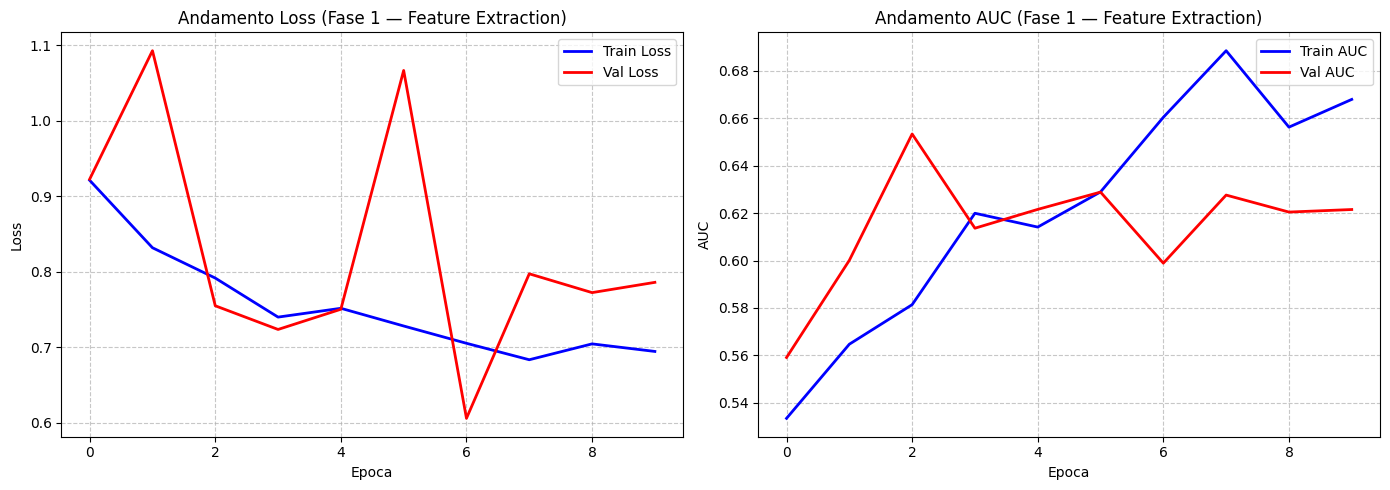

Analisi Overfitting - Fase 2 (Fine Tuning):
Grafico salvato in: ../experiments/exp20260616_baseline_efficientnetb3_fine_tuned_batch_size_16/figures/training_history_fase2.png


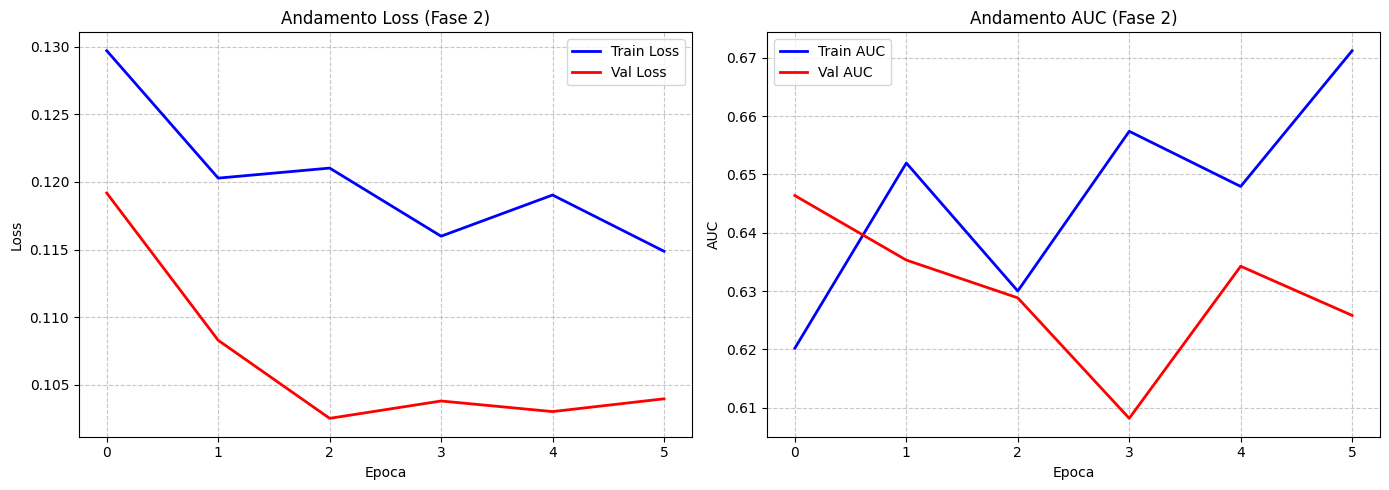

In [11]:
def plot_training_history(history, title_suffix="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title(f'Andamento Loss {title_suffix}')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title(f'Andamento AUC {title_suffix}')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Grafico salvato in: {save_path}")
    plt.show()

FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Analisi Overfitting - Fase 1 (Feature Extraction):")
plot_training_history(
    history_phase1, "(Fase 1 — Feature Extraction)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase1.png')
)

print("Analisi Overfitting - Fase 2 (Fine Tuning):")
plot_training_history(
    history_phase2, "(Fase 2)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase2.png')
)

#### Valutazione su Validation Set

AUC: 0.6467
Soglia ottimale: 0.473
              precision    recall  f1-score   support

   No cancro       0.96      0.29      0.45       364
      Cancro       0.21      0.95      0.35        73

    accuracy                           0.40       437
   macro avg       0.59      0.62      0.40       437
weighted avg       0.84      0.40      0.43       437

Metriche salvate in: ../experiments/exp20260616_baseline_efficientnetb3_fine_tuned_batch_size_16/val_metrics.json


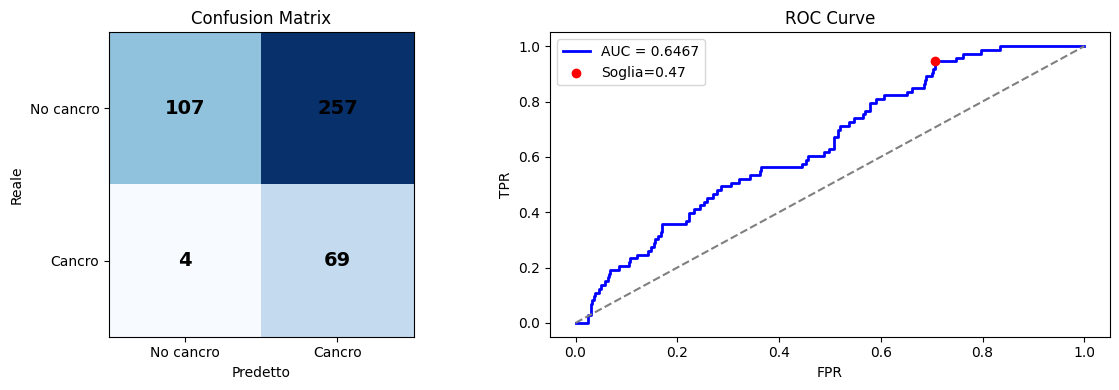

Figura salvata in: ../experiments/exp20260616_baseline_efficientnetb3_fine_tuned_batch_size_16/figures/val_confusion_roc.png


In [12]:
from sklearn.metrics import (confusion_matrix, roc_curve,
                             classification_report, roc_auc_score,
                             precision_score, recall_score, f1_score)

# Carica il miglior modello salvato
best_model = keras.models.load_model(
    os.path.join(OUTPUT_DIR, 'baseline_efficientnetb3_final_best.keras')
)

# Predizioni sul validation set
y_true, y_pred_prob = [], []
for imgs, labels in val_ds:
    preds = best_model.predict(imgs, verbose=0)
    y_pred_prob.extend(preds.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Soglia ottimale (Youden's J)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
youden_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[youden_idx]
y_pred = (y_pred_prob >= best_threshold).astype(int)

val_auc = roc_auc_score(y_true, y_pred_prob)
report_str = classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro'])

print(f"AUC: {val_auc:.4f}")
print(f"Soglia ottimale: {best_threshold:.3f}")
print(report_str)

# Salva metriche in JSON
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

metrics_dict = {
    'split': 'validation',
    'backbone': 'EfficientNetB3',
    'experiment_name': os.path.basename(OUTPUT_DIR),
    'auc': round(float(val_auc), 4),
    'optimal_threshold_youden': round(float(best_threshold), 4),
    'accuracy': round(float((y_pred == y_true).mean()), 4),
    'precision_cancer': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'recall_cancer':    round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'f1_cancer':        round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report_str,
}
metrics_path = os.path.join(OUTPUT_DIR, 'val_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print(f"Metriche salvate in: {metrics_path}")

# Figura: Confusion Matrix + ROC curve
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No cancro', 'Cancro'])
axes[0].set_yticklabels(['No cancro', 'Cancro'])
axes[0].set_xlabel('Predetto'); axes[0].set_ylabel('Reale')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')

axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {val_auc:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].scatter(fpr[youden_idx], tpr[youden_idx], color='red', zorder=5, label=f'Soglia={best_threshold:.2f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'val_confusion_roc.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in: {fig_path}")

#### Grad-CAM

Modello caricato: baseline_efficientnetb3


E0000 00:00:1781644384.025411    1779 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781644386.119187    1779 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781644387.597911    1779 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781644390.093098    1779 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


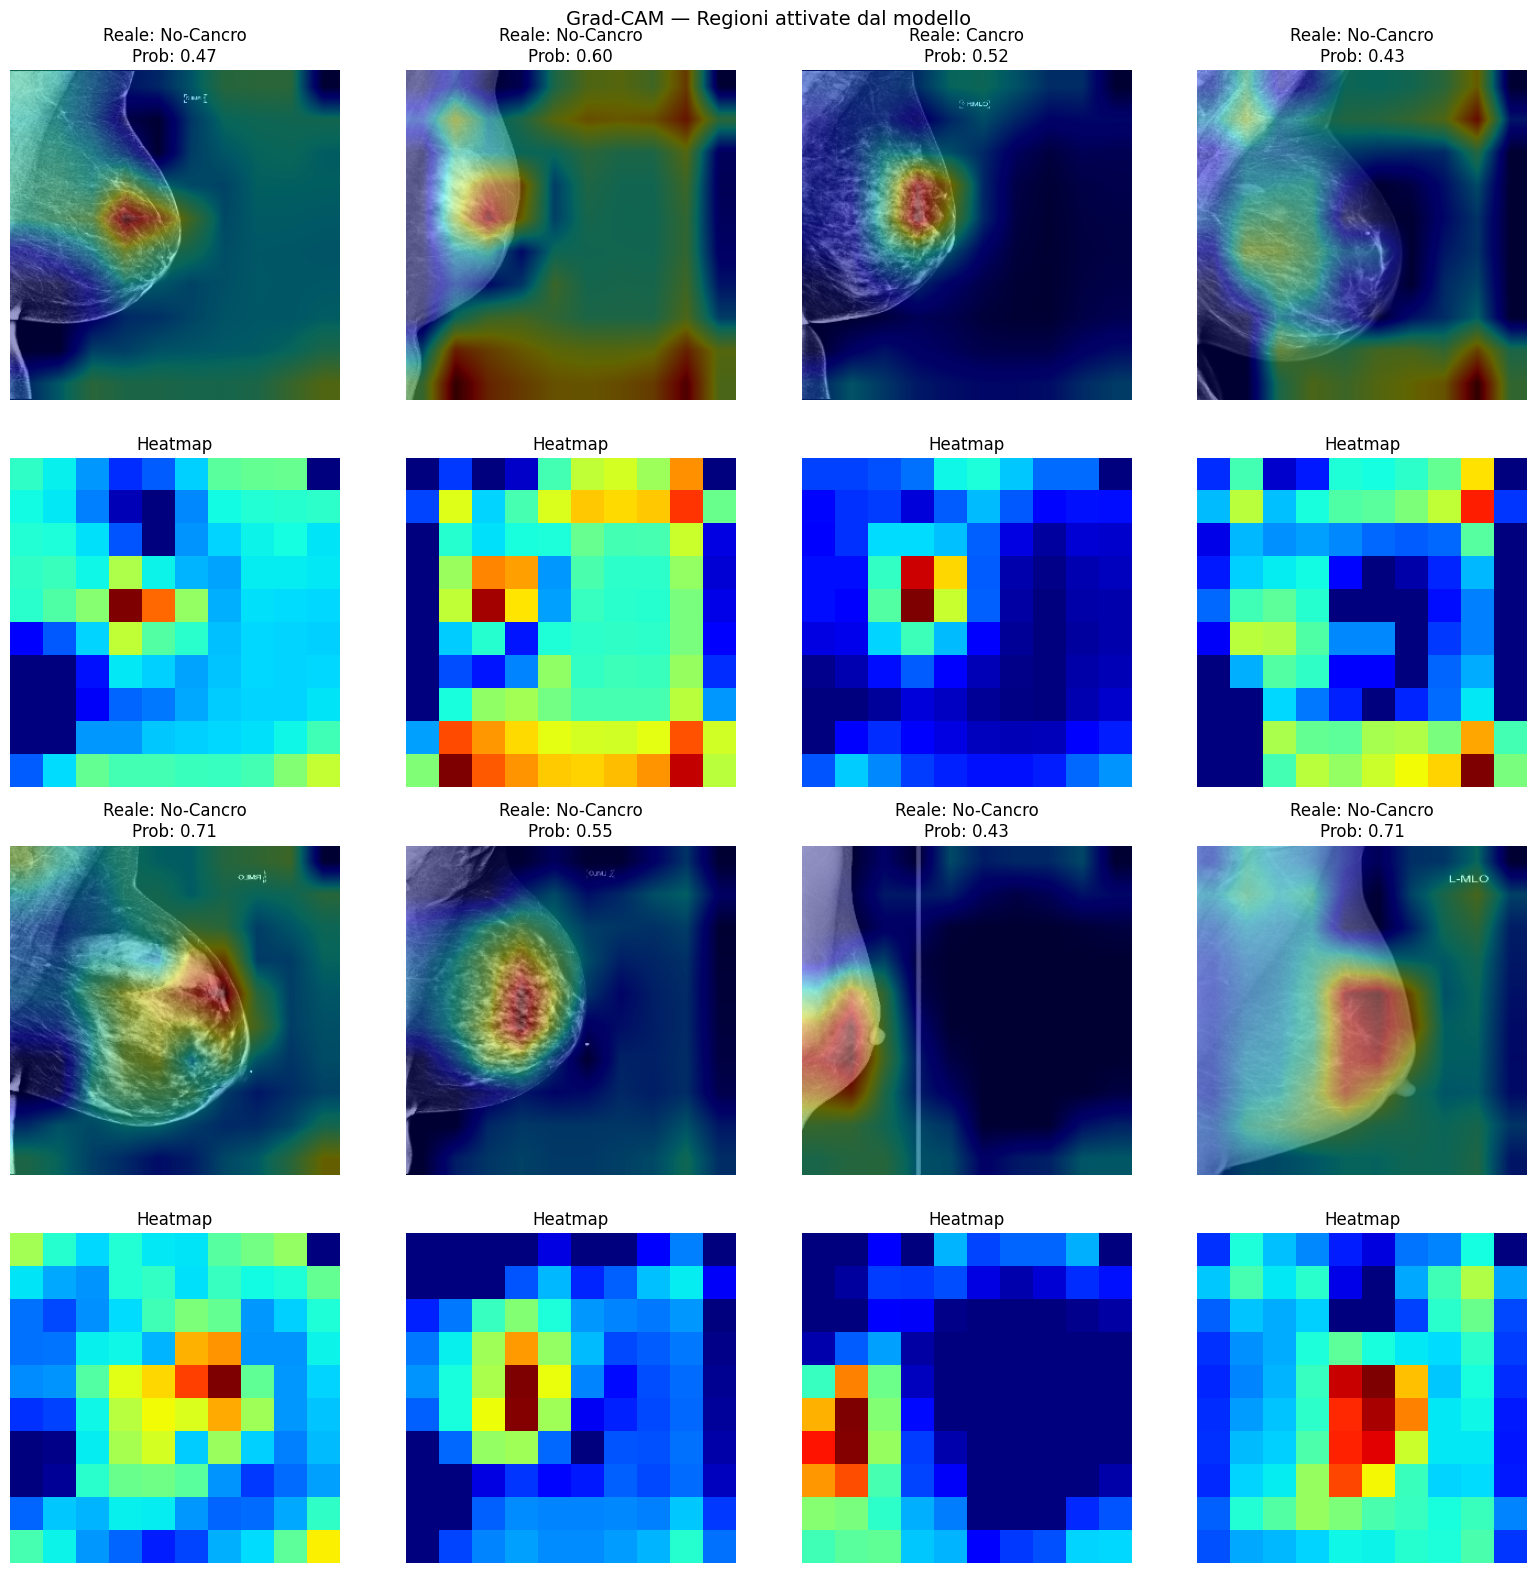

Grad-CAM salvato in: ../experiments/exp20260616_baseline_efficientnetb3_fine_tuned_batch_size_16/figures/gradcam_examples.png


In [ ]:
# Carica il modello già allenato (nessun custom_objects necessario)
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')

best_model = keras.models.load_model(
    os.path.join(OUTPUT_DIR, 'baseline_efficientnetb3_final_best.keras')
)
print(f"Modello caricato: {best_model.name}")


def make_gradcam_heatmap(img_array, model):
    backbone = model.get_layer('efficientnetb3')
    # Layer dopo il backbone nell'outer model: GAP → Dense → BN → LeakyReLU → Dropout → Dense
    head_layers = [l for l in model.layers
                   if l.name not in [model.layers[0].name, backbone.name]]

    with tf.GradientTape() as tape:
        backbone_out = backbone(img_array, training=False)  # (1, H, W, 1536) — ha dimensioni spaziali
        tape.watch(backbone_out)
        x = backbone_out
        for layer in head_layers:
            x = layer(x, training=False)
        predictions = x

    grads = tape.gradient(predictions, backbone_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = backbone_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()



def show_gradcam(img_tensor, heatmap, ax, title=""):
    """Sovrappone la heatmap all'immagine originale de-normalizzata."""
    # De-normalizza per visualizzazione
    img_vis = img_tensor.numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_vis = np.clip(img_vis, 0, 1)
    img_vis_gray = img_vis[:, :, 0]  # canale singolo (mammografia)

    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    ax.imshow(img_vis_gray, cmap='gray')
    ax.imshow(heatmap_resized, cmap='jet', alpha=0.4)
    ax.set_title(title)
    ax.axis('off')


# Mostra Grad-CAM su 8 esempi del validation set
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
sample_count = 0
for imgs, labels in val_ds:
    for i in range(len(imgs)):
        if sample_count >= 8:
            break
        img = imgs[i:i+1]
        label = int(labels[i].numpy())
        prob = float(best_model.predict(img, verbose=0)[0][0])
        heatmap = make_gradcam_heatmap(img, best_model)

        row_img = (sample_count // 4) * 2       # 0 o 2
        row_heat = row_img + 1                  # 1 o 3
        col = sample_count % 4                  # 0,1,2,3

        show_gradcam(imgs[i], heatmap, axes[row_img, col],
                     title=f"Reale: {'Cancro' if label==1 else 'No-Cancro'}\nProb: {prob:.2f}")
        axes[row_heat, col].imshow(heatmap, cmap='jet')
        axes[row_heat, col].set_title("Heatmap")
        axes[row_heat, col].axis('off')
        sample_count += 1
    if sample_count >= 8:
        break

plt.suptitle("Grad-CAM — Regioni attivate dal modello", fontsize=14)
plt.tight_layout()
gradcam_path = os.path.join(FIGURES_DIR, 'gradcam_examples.png')
fig.savefig(gradcam_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM salvato in: {gradcam_path}")
